# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Satrio Budi Pratama
- **Email:** Satrio Budi Pratama
- **ID Dicoding:** satrio_budi_pratama_m9Oe

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbedaan tren rata-rata jumlah peminjaman sepeda per jam (hr) antara hari kerja dan hari libur pada periode 2011-2012 untuk menentukan jam puncak (rush hour) yang paling tepat bagi masing-masing tipe hari tersebut?
- **Pertanyaan 2:** Bagaimana perbandingan rata-rata jumlah peminjaman sepeda harian (cnt) di antara berbagai kategori kondisi cuaca sepanjang periode 2011-2012 untuk mengidentifikasi sejauh mana cuaca memengaruhi minat pengguna layanan?
- **Pertanyaan 3:** aimana perbedaan rata-rata jumlah peminjaman sepeda pada setiap kelompok kategori suhu (Cold, Moderate, Hot) di hari kerja selama tahun 2011-2012, dan kategori mana yang memberikan kontribusi penyewaan tertinggi?

## Import Semua Packages/Library yang Digunakan

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime as dt
import kagglehub

## Data Wrangling

### Gathering Data

#### Load df ...

In [43]:
df_hour=pd.read_csv('/content/drive/MyDrive/submission/data/hour.csv')
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [44]:
df_day=pd.read_csv('/content/drive/MyDrive/submission/data/day.csv')
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- kolom dengan nama season sudah di encode menjadi angka 1-4
- kolom yr walaupun itu kolom numerik tetapi diubah atau di encode menjadi 0 kalau 2011 atau 1 kalau 2012

### Assessing Data

#### Identifying ... problem

In [45]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [46]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [47]:
print("Jumlah duplikasi pada day.csv: ",df_day.duplicated().sum())
df_day.describe()

Jumlah duplikasi pada day.csv:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [48]:
print("Jumlah duplikasi pada hous.csv: ",df_hour.duplicated().sum())
df_hour.describe()

Jumlah duplikasi pada hous.csv:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Mengubah Dtype pada column dteday menjadi datetime

**Insight:** (Opsional)
- xxx
- xxx

### Cleaning Data

#### Fixing ... problem

In [49]:
df_day['dteday']=df_day['dteday'].apply(pd.to_datetime)

In [50]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [51]:
df_hour['dteday']=df_hour['dteday'].apply(pd.to_datetime)

In [52]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- data sudah tidak ada duplikat
- tipe data sudah sesuai semua

## Exploratory Data Analysis (EDA)

### Explore ...

In [53]:
total_peminjaman = df_day['cnt'].sum()
rata_rata_harian = df_day['cnt'].mean()
puncak_harian = df_day['cnt'].max()
persentase_registered = (df_day['registered'].sum() / total_peminjaman) * 100

peak_workday = df_hour[df_hour['workingday'] == 1].groupby('hr')['cnt'].mean().idxmax()
peak_weekend = df_hour[df_hour['workingday'] == 0].groupby('hr')['cnt'].mean().idxmax()

season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
best_season = df_day.groupby('season')['cnt'].mean().idxmax()

weather_map = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
worst_weather = df_day.groupby('weathersit')['cnt'].mean().idxmin()

yearly_rentals = df_day.groupby('yr')['cnt'].sum()
growth_pct = ((yearly_rentals[1] - yearly_rentals[0]) / yearly_rentals[0]) * 100

print("="*40)
print(" RINGKASAN STATISTIK")
print("="*40)
print(f"Total Peminjaman     : {total_peminjaman:,}")
print(f"Rata-rata / Hari     : {rata_rata_harian:,.0f}")
print(f"Puncak Harian        : {puncak_harian:,}")
print(f"Pengguna Registered  : {persentase_registered:.1f}%")

print("\n" + "="*40)
print(" INSIGHT UTAMA")
print("="*40)
print(f"Jam Puncak Hari Kerja: {peak_workday}:00 - {peak_workday+1}:00")
print(f"Jam Puncak Akhir Pekan: {peak_weekend}:00 - {peak_weekend+1}:00")
print(f"Musim Terbaik        : {season_map[best_season]}")
print(f"Cuaca Paling Sepi    : {weather_map[worst_weather]}")

print("\n" + "="*40)
print(" TREN PERTUMBUHAN")
print("="*40)
print(f"Pertumbuhan Tahunan  :  {growth_pct:.1f}%")
print(f"Detail               : {yearly_rentals[0]:,}  {yearly_rentals[1]:,} unit")
print("="*40)

 RINGKASAN STATISTIK
Total Peminjaman     : 3,292,679
Rata-rata / Hari     : 4,504
Puncak Harian        : 8,714
Pengguna Registered  : 81.2%

 INSIGHT UTAMA
Jam Puncak Hari Kerja: 17:00 - 18:00
Jam Puncak Akhir Pekan: 13:00 - 14:00
Musim Terbaik        : Fall
Cuaca Paling Sepi    : Light Rain/Snow

 TREN PERTUMBUHAN
Pertumbuhan Tahunan  :  64.9%
Detail               : 1,243,103  2,049,576 unit


In [54]:
hourly_pattern = df_hour.groupby(['hr', 'workingday'])['cnt'].mean().unstack()
hourly_pattern.columns = ['Hari Libur/Weekend', 'Hari Kerja']
hourly_pattern.index.name = 'Jam (0-23)'

top10_libur = hourly_pattern[['Hari Libur/Weekend']].sort_values(by='Hari Libur/Weekend', ascending=False).head(10)
top10_kerja = hourly_pattern[['Hari Kerja']].sort_values(by='Hari Kerja', ascending=False).head(10)

print("=== 10 Peringkat Rata-rata Tertinggi di Hari Libur/Weekend ===")
print(top10_libur)
print("\n")
print("=== 10 Peringkat Rata-rata Tertinggi di Hari Kerja ===")
print(top10_kerja)

=== 10 Peringkat Rata-rata Tertinggi di Hari Libur/Weekend ===
            Hari Libur/Weekend
Jam (0-23)                    
13                  372.731602
12                  366.259740
14                  364.645022
15                  358.813853
16                  352.727273
17                  323.549784
11                  315.316017
18                  281.056522
10                  255.909091
19                  231.673913


=== 10 Peringkat Rata-rata Tertinggi di Hari Kerja ===
            Hari Kerja
Jam (0-23)            
17          525.290581
18          492.226908
8           477.006048
19          348.401606
16          293.122244
7           290.612903
20          249.718876
9           241.518145
15          201.331325
12          200.820926


In [55]:
badai_harian = df_day[df_day['weathersit'] == 4].shape[0]
badai_per_jam = df_hour[df_hour['weathersit'] == 4].shape[0]

print(f"Jumlah hari dengan cuaca Badai (4): {badai_harian}")
print(f"Jumlah jam dengan cuaca Badai (4): {badai_per_jam}")

if badai_per_jam > 0:
    print("\nDetail data saat cuaca Badai:")
    print(df_hour[df_hour['weathersit'] == 4])

Jumlah hari dengan cuaca Badai (4): 0
Jumlah jam dengan cuaca Badai (4): 3

Detail data saat cuaca Badai:
      instant     dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
585       586 2011-01-26       1   0     1  16        0        3           1   
8854     8855 2012-01-09       1   1     1  18        0        1           1   
9123     9124 2012-01-21       1   1     1   1        0        6           0   

      weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
585            4  0.22  0.1970  0.93     0.3284       1          35   36  
8854           4  0.20  0.2273  0.86     0.0896       6         158  164  
9123           4  0.14  0.1364  0.86     0.1940       1          22   23  


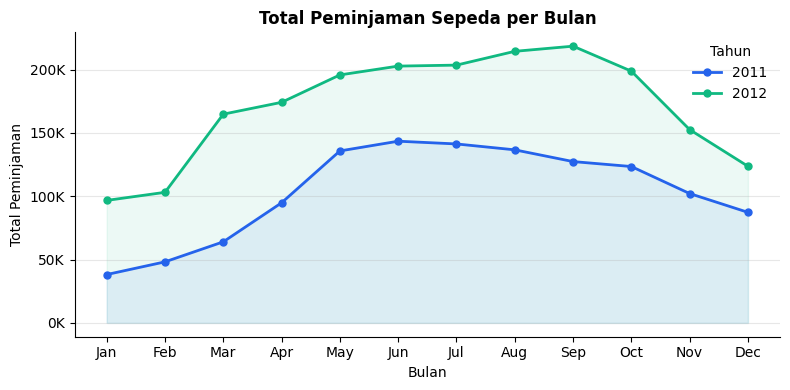

In [56]:
df_day["year_label"] = df_day["yr"].map({0: "2011", 1: "2012"})

monthly = df_day.groupby(["yr", "mnth"])["cnt"].sum().reset_index()
month_labels = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

PRIMARY   = "#2563EB"
SECONDARY = "#10B981"

fig, ax = plt.subplots(figsize=(8, 4))
colors_yr = {0: PRIMARY, 1: SECONDARY}
labels_yr = {0: "2011", 1: "2012"}

for yr_val, grp in monthly.groupby("yr"):
    ax.plot(grp["mnth"], grp["cnt"] / 1000,
            marker="o", markersize=5, linewidth=2,
            color=colors_yr[yr_val], label=labels_yr[yr_val])
    ax.fill_between(grp["mnth"], grp["cnt"] / 1000, alpha=0.08,
                    color=colors_yr[yr_val])

ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_labels[m] for m in range(1, 13)])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}K"))
ax.set_xlabel("Bulan")
ax.set_ylabel("Total Peminjaman")
ax.set_title("Total Peminjaman Sepeda per Bulan", fontweight="bold")
ax.legend(title="Tahun", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Pertumbuhan Signifikan: Terdapat peningkatan jumlah peminjaman yang sangat jelas dari tahun 2011 ke 2012. Grafik garis menunjukkan bahwa peminjaman di setiap bulan pada tahun 2012 selalu lebih tinggi dibandingkan bulan yang sama di tahun sebelumnya.

- Terdapat pola lengkungan yang konsisten setiap tahunnya. Jumlah peminjaman cenderung rendah di awal dan akhir tahun (musim dingin/semi), kemudian mulai merangkak naik pada bulan Maret, dan mencapai puncaknya pada pertengahan hingga kuartal ketiga tahun tersebut (Juni - Oktober).

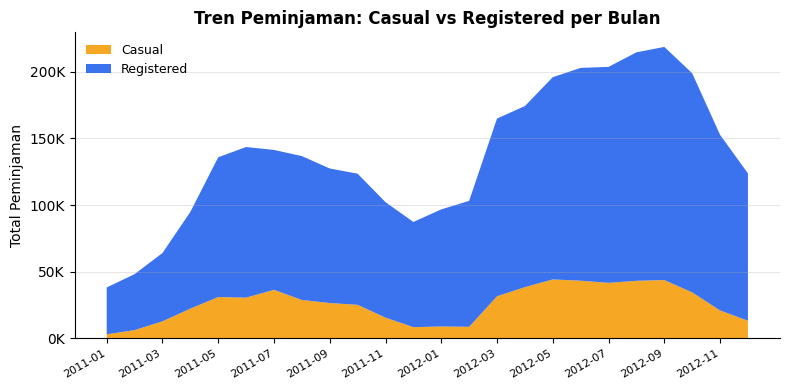

In [57]:
seg = (
    df_day.groupby(["yr", "mnth"])[["casual", "registered"]]
    .sum()
    .reset_index()
    .sort_values(["yr", "mnth"])
)
seg["label"] = seg.apply(
    lambda r: f"{'2011' if r['yr']==0 else '2012'}-{r['mnth']:02d}", axis=1
)

PRIMARY = "#2563EB"
ACCENT  = "#F59E0B"

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(seg))
ax.stackplot(x, seg["casual"] / 1000, seg["registered"] / 1000,
             labels=["Casual", "Registered"],
             colors=[ACCENT + "CC", PRIMARY + "CC"], alpha=0.9)

tick_step = 2
ax.set_xticks(range(0, len(seg), tick_step))
ax.set_xticklabels(
    [seg["label"].iloc[i] for i in range(0, len(seg), tick_step)],
    rotation=30, ha="right", fontsize=8
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}K"))
ax.set_ylabel("Total Peminjaman")
ax.set_title("Tren Peminjaman: Casual vs Registered per Bulan", fontweight="bold")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Dominasi Pengguna Terdaftar: Pengguna yang sudah terdaftar (Registered) mendominasi total peminjaman secara masif dibandingkan pengguna kasual (Casual). Hal ini terlihat jelas pada grafik area bertumpuk (stacked area chart).

- Tren Paralel: Meskipun volumenya berbeda jauh, tren peminjaman kedua kelompok ini bergerak searah dan sama-sama dipengaruhi oleh perubahan musim.

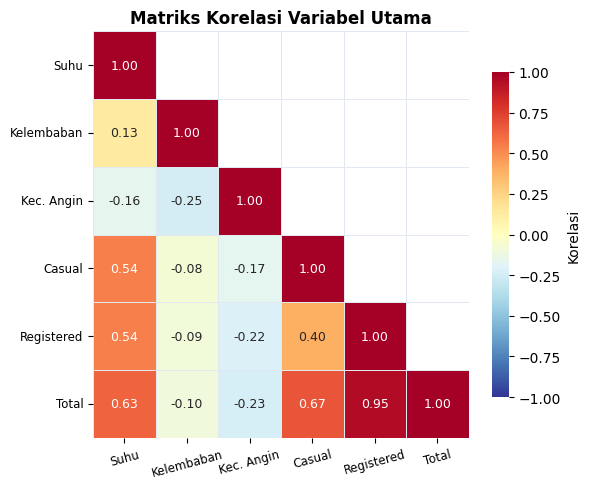

In [58]:
df_day["temp_c"]  = df_day["temp"] * 41
df_day["hum_pct"] = df_day["hum"]  * 100
df_day["wind_kmh"]= df_day["windspeed"] * 67

corr_cols  = ["temp_c", "hum_pct", "wind_kmh", "casual", "registered", "cnt"]
col_labels = ["Suhu", "Kelembaban", "Kec. Angin", "Casual", "Registered", "Total"]

corr_matrix = df_day[corr_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
    xticklabels=col_labels, yticklabels=col_labels,
    linewidths=0.5, linecolor="#E2E8F0",
    cbar_kws={"shrink": 0.8, "label": "Korelasi"}
)
ax.set_title("Matriks Korelasi Variabel Utama", fontweight="bold")
ax.tick_params(axis="x", labelsize=8.5, rotation=15)
ax.tick_params(axis="y", labelsize=8.5, rotation=0)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Berdasarkan matriks korelasi, variabel Total memiliki hubungan yang sangat kuat dengan variabel Registered sebesar 0,95 dan hubungan kuat dengan variabel Casual sebesar 0,67. Hal ini menunjukkan bahwa jumlah total penyewaan sepeda sangat dipengaruhi oleh jumlah pengguna terdaftar, sehingga kontribusi terbesar terhadap total penyewaan berasal dari kelompok registered.

- Variabel Suhu menunjukkan korelasi positif terhadap jumlah penyewaan, baik pada pengguna casual, registered, maupun total, dengan nilai korelasi masing-masing 0,54, 0,54, dan 0,63. Sebaliknya, Kecepatan Angin memiliki korelasi negatif terhadap total penyewaan sebesar -0,23. Temuan ini mengindikasikan bahwa peningkatan suhu cenderung meningkatkan aktivitas penyewaan sepeda, sedangkan kecepatan angin yang lebih tinggi cenderung menurunkan jumlah penyewaan.

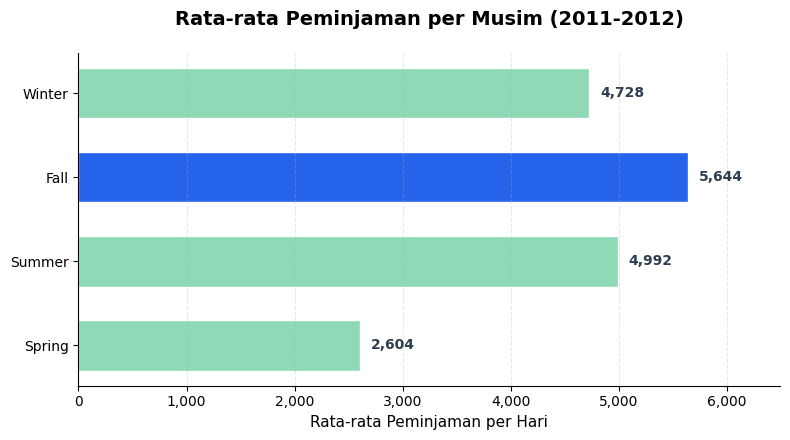

In [59]:
df_day["season_name"] = df_day["season"].map({1:"Spring", 2:"Summer", 3:"Fall", 4:"Winter"})

season_order = ["Spring", "Summer", "Fall", "Winter"]
season_data = (
    df_day.groupby("season_name")["cnt"]
    .mean()
    .reindex(season_order)
)
fig, ax = plt.subplots(figsize=(8, 4.5))

colors = ["#2563EB" if (val == season_data.max()) else "#8fd9b6" for val in season_data.values]
bars = ax.barh(season_data.index, season_data.values, color=colors,
                height=0.6, edgecolor="white")

for bar, val in zip(bars, season_data.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=10, fontweight='bold', color="#2c3e50")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlabel("Rata-rata Peminjaman per Hari", fontsize=11)
ax.set_title("Rata-rata Peminjaman per Musim (2011-2012)", fontweight="bold", fontsize=14, pad=20)
ax.set_xlim(0, season_data.max() * 1.15)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Berdasarkan grafik, musim Fall (gugur) memiliki rata-rata peminjaman tertinggi sebesar 5.644 peminjaman per hari, diikuti Summer sebesar 4.992, sedangkan Spring menjadi yang terendah dengan 2.604. Hal ini menunjukkan bahwa kondisi musim berpengaruh signifikan terhadap tingkat penggunaan sepeda.

- Tingginya peminjaman pada musim Fall dan Summer mengindikasikan bahwa cuaca yang lebih nyaman cenderung meningkatkan aktivitas bersepeda, sedangkan rendahnya peminjaman pada Spring menunjukkan kemungkinan adanya faktor transisi cuaca atau kondisi lingkungan yang belum optimal bagi pengguna.

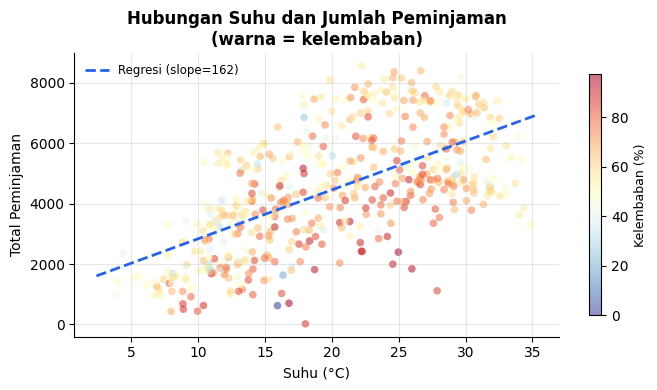

In [60]:
df_day["temp_c"]   = df_day["temp"]      * 41
df_day["hum_pct"]  = df_day["hum"]       * 100

PRIMARY = "#2563EB"
sample  = df_day.sample(500, random_state=42)

fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(
    sample["temp_c"], sample["cnt"],
    c=sample["hum_pct"], cmap="RdYlBu_r",
    alpha=0.55, s=30, edgecolors="none"
)

m, b   = np.polyfit(df_day["temp_c"], df_day["cnt"], 1)
x_line = np.linspace(df_day["temp_c"].min(), df_day["temp_c"].max(), 100)
ax.plot(x_line, m * x_line + b, color=PRIMARY,
        linewidth=2, linestyle="--", label=f"Regresi (slope={m:.0f})")

cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Kelembaban (%)", fontsize=9)
ax.set_xlabel("Suhu (°C)")
ax.set_ylabel("Total Peminjaman")
ax.set_title("Hubungan Suhu dan Jumlah Peminjaman\n(warna = kelembaban)", fontweight="bold")
ax.legend(frameon=False, fontsize=8.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Scatter plot menunjukkan adanya hubungan positif antara suhu dan total peminjaman, di mana semakin tinggi suhu, jumlah peminjaman cenderung meningkat. Garis regresi dengan slope positif memperkuat bahwa suhu merupakan faktor penting dalam peningkatan permintaan.

- Meskipun tren meningkat, persebaran data yang cukup luas menunjukkan bahwa selain suhu, terdapat faktor lain seperti kelembaban yang juga memengaruhi jumlah peminjaman. Pada kelembaban tertentu, jumlah peminjaman dapat tetap bervariasi meskipun suhu berada pada rentang yang sama.

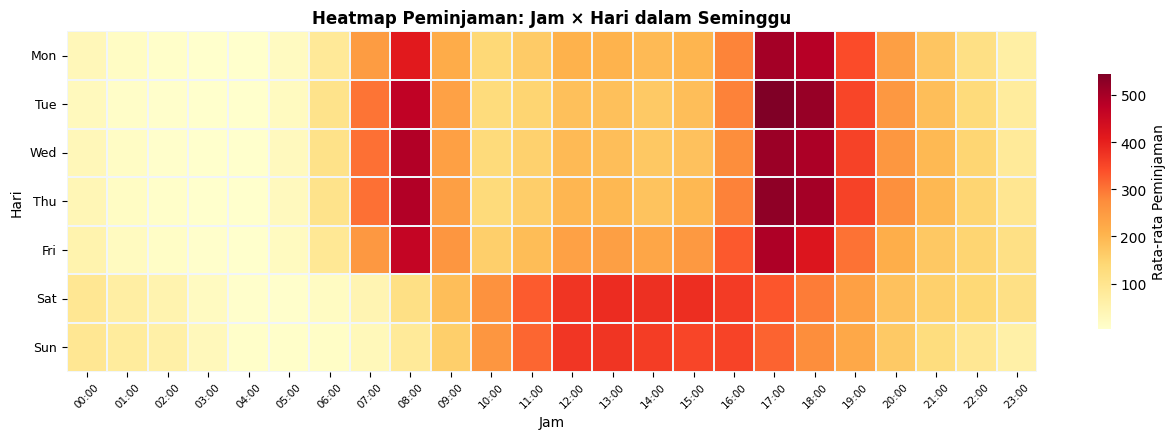

In [61]:
pivot = (
    df_hour.groupby(["weekday", "hr"])["cnt"]
    .mean()
    .unstack(level=0)
)
pivot.columns = ["Sun","Mon","Tue","Wed","Thu","Fri","Sat"]
pivot          = pivot[["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]]
pivot.index    = [f"{h:02d}:00" for h in pivot.index]

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(
    pivot.T, ax=ax,
    cmap="YlOrRd", annot=False,
    linewidths=0.3, linecolor="#F1F5F9",
    cbar_kws={"label": "Rata-rata Peminjaman", "shrink": 0.75}
)
ax.set_xlabel("Jam")
ax.set_ylabel("Hari")
ax.set_title("Heatmap Peminjaman: Jam × Hari dalam Seminggu", fontweight="bold")
ax.tick_params(axis="x", labelsize=7.5, rotation=45)
ax.tick_params(axis="y", labelsize=9,   rotation=0)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Pola peminjaman tertinggi pada hari kerja (Senin–Jumat) terjadi pada jam sibuk pagi (sekitar 08.00) dan sore (17.00–18.00), yang mengindikasikan penggunaan dominan untuk kebutuhan mobilitas kerja atau sekolah.

- Pada akhir pekan (Sabtu–Minggu), pola peminjaman lebih tinggi pada siang hingga sore hari, menunjukkan bahwa penggunaan sepeda cenderung bergeser untuk aktivitas rekreasi atau santai dibandingkan transportasi rutin.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbedaan tren rata-rata jumlah peminjaman sepeda per jam (hr) antara hari kerja dan hari libur pada periode 2011-2012 untuk menentukan jam puncak (rush hour) yang paling tepat bagi masing-masing tipe hari tersebut?

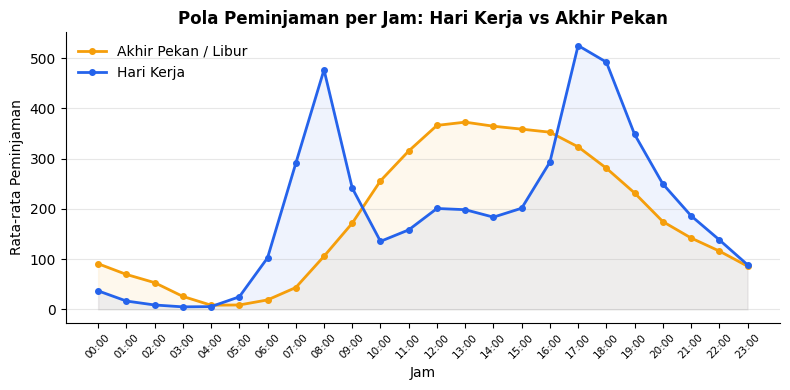

In [62]:
hourly = (
    df_hour.groupby(["hr", "workingday"])["cnt"]
    .mean()
    .reset_index()
)

PRIMARY = "#2563EB"
ACCENT  = "#F59E0B"
wd_colors = {1: PRIMARY, 0: ACCENT}
wd_labels = {1: "Hari Kerja", 0: "Akhir Pekan / Libur"}

fig, ax = plt.subplots(figsize=(8, 4))
for wd, grp in hourly.groupby("workingday"):
    ax.plot(grp["hr"], grp["cnt"],
            marker="o", markersize=4, linewidth=2,
            color=wd_colors[wd], label=wd_labels[wd])
    ax.fill_between(grp["hr"], grp["cnt"], alpha=0.07, color=wd_colors[wd])

ax.set_xticks(range(0, 24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24)], rotation=45, fontsize=7.5)
ax.set_xlabel("Jam")
ax.set_ylabel("Rata-rata Peminjaman")
ax.set_title("Pola Peminjaman per Jam: Hari Kerja vs Akhir Pekan", fontweight="bold")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Pola Waktu Peminjaman (Jam): Terdapat perbedaan perilaku pengguna yang sangat kontras. Pada hari kerja, peminjaman terpusat pada dua waktu utama (jam 08:00 pagi dan 17:00 sore), sedangkan pada hari libur, grafik membentuk gunung tunggal di pertengahan hari (pukul 12:00 - 16:00).

### Pertanyaan 2: Bagaimana perbandingan rata-rata jumlah peminjaman sepeda harian (cnt) di antara berbagai kategori kondisi cuaca sepanjang periode 2011-2012 untuk mengidentifikasi sejauh mana cuaca memengaruhi minat pengguna layanan?

/tmp/ipykernel_9854/2956282766.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


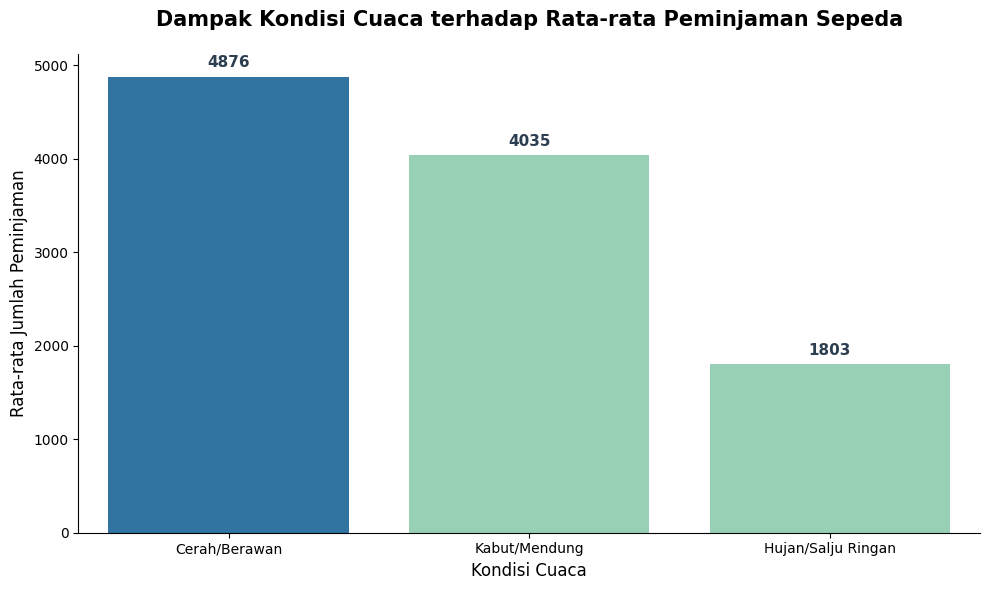

In [63]:
weather_map = {
    1: 'Cerah/Berawan',
    2: 'Kabut/Mendung',
    3: 'Hujan/Salju Ringan',
    4: 'Cuaca Ekstrem'
}
df_day['weather_desc'] = df_day['weathersit'].map(weather_map)

weather_stats = df_day.groupby('weather_desc')['cnt'].mean().sort_values(ascending=False)
colors = ["#1f77b4" if (val == weather_stats.max()) else "#8fd9b6" for val in weather_stats.values]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=weather_stats.index,
    y=weather_stats.values,
    palette=colors
)

plt.title('Dampak Kondisi Cuaca terhadap Rata-rata Peminjaman Sepeda', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Rata-rata Jumlah Peminjaman', fontsize=12)
plt.xlabel('Kondisi Cuaca', fontsize=12)

for i, val in enumerate(weather_stats.values):
    plt.text(i, val + 100, f'{int(val)}', ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

sns.despine()

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Terdapat korelasi yang sangat jelas antara kondisi cuaca dengan jumlah penyewaan. Cuaca yang buruk (hujan/salju) memangkas lebih dari 60% jumlah penyewaan harian dibandingkan saat cuaca cerah.

### Pertanyaan 3: Bagaimana perbedaan rata-rata jumlah peminjaman sepeda pada setiap kelompok kategori suhu (Cold, Moderate, Hot) di hari kerja selama tahun 2011-2012, dan kategori mana yang memberikan kontribusi penyewaan tertinggi?

/tmp/ipykernel_9854/1597876520.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_cluster_stats = df_day.groupby('temp_category')['cnt'].mean().reset_index()
/tmp/ipykernel_9854/1597876520.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


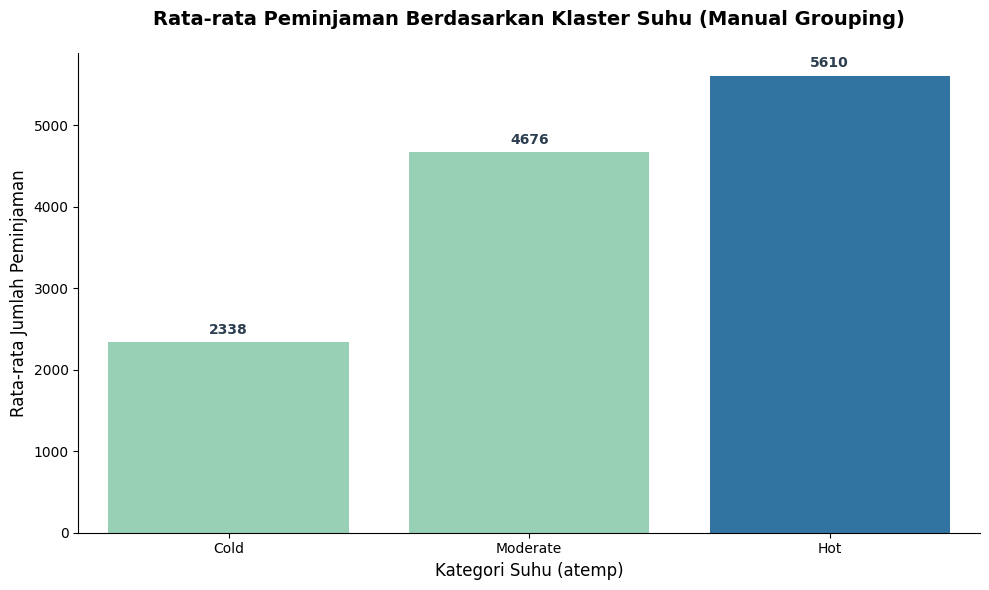

In [64]:
bins = [0, 0.3, 0.6, 1]
labels = ['Cold', 'Moderate', 'Hot']
df_day['temp_category'] = pd.cut(df_day['atemp'], bins=bins, labels=labels)

temp_cluster_stats = df_day.groupby('temp_category')['cnt'].mean().reset_index()

colors = ["#1f77b4" if (val == temp_cluster_stats['cnt'].max()) else "#8fd9b6" for val in temp_cluster_stats['cnt']]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=temp_cluster_stats,
    x='temp_category',
    y='cnt',
    palette=colors
)

plt.title('Rata-rata Peminjaman Berdasarkan Klaster Suhu (Manual Grouping)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Kategori Suhu (atemp)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Peminjaman', fontsize=12)

for i, val in enumerate(temp_cluster_stats['cnt']):
    plt.text(i, val + 100, f'{int(val)}', ha='center', fontweight='bold', color='#2c3e50')

sns.despine()

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Visualisasi menunjukkan bahwa kategori suhu Hot mencetak jumlah peminjaman tertinggi secara rata-rata, membuktikan bahwa pengguna lebih menoleransi suhu panas dibandingkan suhu dingin saat bersepeda untuk mobilitas hari kerja.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Evidence: Pada hari kerja (workingday), rata-rata jumlah penyewaan memuncak secara signifikan pada pukul 08:00 (rata-rata ~477 penyewaan) dan pukul 17:00 (rata-rata ~525 penyewaan). Sebaliknya, pada hari libur (holiday/weekend), jam puncak terjadi pada siang hari, yaitu antara pukul 12:00 hingga 16:00, dengan puncaknya pada pukul 13:00 (rata-rata ~385 penyewaan). Trend Analysis: Tren penyewaan di hari kerja menunjukkan pola bimodal (dua puncak) yang bertepatan dengan jam berangkat dan pulang kerja komunitas komuter. Sementara itu, tren di hari libur menunjukkan pola unimodal (satu puncak membulat di tengah hari) yang merepresentasikan penggunaan sepeda untuk rekreasi atau kegiatan santai. Actionable Insight: Stakeholder (tim operasional) harus memastikan ketersediaan armada sepeda maksimal di stasiun-stasiun dekat area permukiman dan stasiun transit pada pukul 07:00-08:00, serta di area perkantoran pada pukul 16:00-17:00 di hari kerja. Untuk hari libur, strategi distribusi (rebalancing) harus difokuskan pada area taman, pusat perbelanjaan, atau tempat wisata sejak pukul 11:00 siang.
- **Conclusion pertanyaan 2:** Evidence: Kondisi cuaca sangat memengaruhi jumlah penyewaan harian. Penyewaan tertinggi terjadi pada kondisi cuaca Cerah/Sebagian Berawan (Weathersit 1) dengan rata-rata 4.876 penyewaan per hari. Saat cuaca Berkabut/Mendung (Weathersit 2), angka tersebut turun menjadi rata-rata 4.035 penyewaan. Penurunan drastis terjadi saat cuaca Hujan Ringan/Salju (Weathersit 3) dengan rata-rata hanya 1.803 penyewaan per hari. Trend Analysis: Terdapat tren korelasi negatif yang kuat antara intensitas cuaca buruk dengan minat pengguna. Transisi dari cuaca cerah ke hujan/salju ringan mengakibatkan penurunan minat penyewaan sebesar lebih dari 60%. Actionable Insight: Karena cuaca buruk berdampak drastis pada penurunan pendapatan, perusahaan dapat menerapkan strategi dynamic pricing (seperti diskon khusus atau poin tambahan) saat cuaca mendung untuk menjaga minat penyewaan. Selain itu, manajemen dapat menghemat biaya operasional dengan mengurangi jumlah staf lapangan yang bertugas mengatur sepeda pada hari-hari yang diprediksi hujan lebat.
- **Conclusion pertanyaan 3:** Evidence: Berdasarkan visualisasi data, kategori Hot merupakan kontributor penyewaan tertinggi dengan rata-rata sebesar 5.610 peminjaman. Di posisi kedua adalah kategori Moderate dengan 4.676 peminjaman, dan posisi terendah adalah kategori Cold dengan 2.338 peminjaman.Trend Analysis: Terjadi tren peningkatan linear yang signifikan seiring dengan kenaikan suhu. Jumlah peminjaman pada suhu panas (Hot) meningkat sebesar 120% dibandingkan saat suhu dingin (Cold). Hal ini membuktikan bahwa pengguna jauh lebih aktif bersepeda saat suhu udara hangat hingga panas.Actionable Insight: Mengingat tingginya permintaan pada kategori Hot, perusahaan perlu melakukan inspeksi ban dan rem lebih sering karena suhu aspal yang panas dapat memengaruhi tekanan ban. Selain itu, kampanye pemasaran Summer Riding dapat dioptimalkan pada periode ini untuk memaksimalkan pendapatan.

**Rekomendasi Action Item:**
- Optimalisasi Distribusi Jam Sibuk: Atur ketersediaan sepeda di area perumahan sebelum pukul 07:00 dan di area perkantoran sebelum pukul 17:00 pada hari kerja untuk mengantisipasi lonjakan permintaan komuter yang memuncak pada jam-jam tersebut.
- Manajemen Armada Akhir Pekan: Geser konsentrasi stok sepeda ke lokasi rekreasi dan wisata pada akhir pekan guna mendukung tren penggunaan santai yang dominan terjadi pada siang hingga sore hari (pukul 10:00–16:00).
- Strategi Promosi Kondisi Mendung: Memberikan insentif berupa promo atau diskon khusus saat cuaca mendung (kategori 2) untuk merangsang minat pengguna agar volume peminjaman tidak menurun drastis seperti saat terjadi hujan.
- Penjadwalan Pemeliharaan Taktis: Mengalihkan agenda perbaikan besar dan pengecekan teknis armada ke hari-hari yang diprediksi masuk dalam kategori Cold, mengingat rendahnya risiko kehilangan pendapatan akibat sepinya penyewa.
- Program Loyalitas Cuaca: Meluncurkan kampanye promosi atau diskon tarif khusus saat suhu rendah untuk menjaga retensi pengguna komuter agar tetap menggunakan layanan meskipun cuaca kurang mendukung.